In [ ]:
!pip install h5py
!pip install mne

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import mne

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Data Loading & Analysis

## Single file

<class 'numpy.ndarray'>
(248, 35624)
Bad channels: [236]


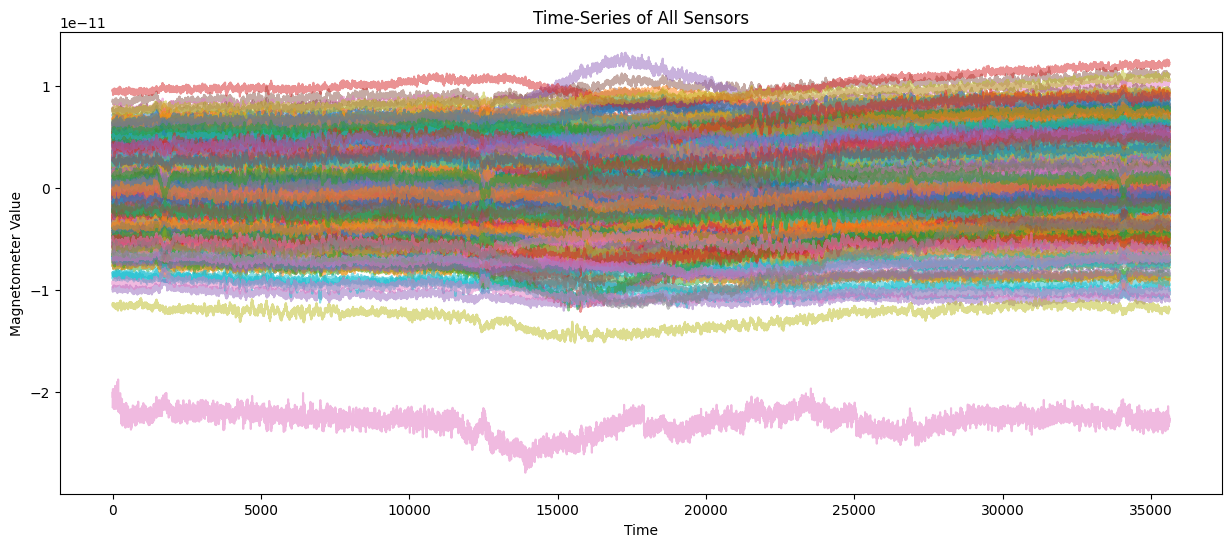

In [35]:
def get_dataset_name(filename_with_dir):
    filename_without_dir = filename_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = '_'.join(temp)
    return dataset_name

filename_path = 'C:/Users/jagod/Desktop/UNI/BlockIV/DL/Seminar/project2/data/Intra/train/rest_105923_1.h5'


with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)


plt.figure(figsize=(15, 6))

bad = []
for i in range(matrix.shape[0]):  # 248 sensors (rows)
    plt.plot(matrix[i], alpha=0.5)  # `alpha` adds transparency to avoid overlap
    if np.max(np.abs(matrix[i])) > 2e-11:
        bad.append(i)


print('Bad channels:', bad)

plt.xlabel('Time')
plt.ylabel('Magnetometer Value')
plt.title('Time-Series of All Sensors')
plt.show()



## All files >> to MNE 

In [43]:
intra_train_dir = 'C:/Users/jagod/Desktop/UNI/BlockIV/DL/Seminar/project2/data/Intra/train'
intra_test_dir = 'C:/Users/jagod/Desktop/UNI/BlockIV/DL/Seminar/project2/data/Intra/test'


# Constants
sfreq = 2034  # Hz >> for downsampling later
n_channels = 248 # channel = sensor
ch_names = [f'MEG {i:03d}' for i in range(n_channels)]
ch_types = ['mag'] * n_channels
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types, verbose=False)


# extract full task label (e.g., task_motor, rest)
def get_task_label(filename):
    parts = filename.split('_')
    if parts[0] == 'rest':
        return 'rest'
    elif parts[0] == 'task':
        label_parts = []
        for part in parts[1:]:
            if part.isdigit():
                break
            label_parts.append(part)
        return '_'.join(label_parts)
    else:
        return 'unknown'


# extract dataset name inside HDF5 file
def get_dataset_name(filename):
    return '_'.join(filename.split('_')[:-1])


def create_dataset(data_dir):

  # File listing
  files = [f for f in os.listdir(data_dir) if f.endswith('.h5')]

  raws = []     # MNE Raw objects
  labels = []   # Task labels



  # Loop through files
  for fname in sorted(files):
      fpath = os.path.join(data_dir, fname)
      task_label = get_task_label(fname)

      with h5py.File(fpath, 'r') as f:
          dataset_name = get_dataset_name(fname)
          data = f[dataset_name][()]  # shape: (248, 35624)

      # Create MNE Raw object
      raw = mne.io.RawArray(data, info, verbose=0)

      # Store
      raws.append(raw)
      labels.append(task_label)

  return raws, labels, info

raws, labels, info = create_dataset(intra_train_dir)

Effective window size : 1.007 (s)
Plotting power spectral density (dB=True).


C:\Users\jagod\AppData\Local\Temp\ipykernel_10720\1476651837.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raws[0].compute_psd(fmax=125).plot(picks="data", amplitude=False)
c:\Users\jagod\Desktop\UNI\BlockIV\DL\Seminar\project2\venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


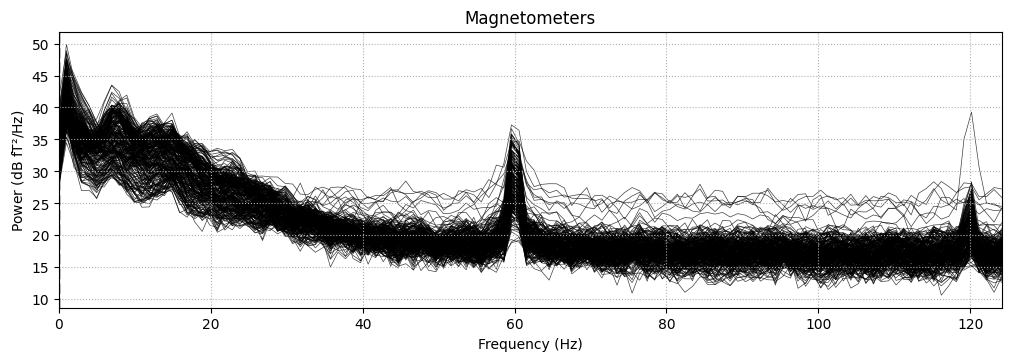

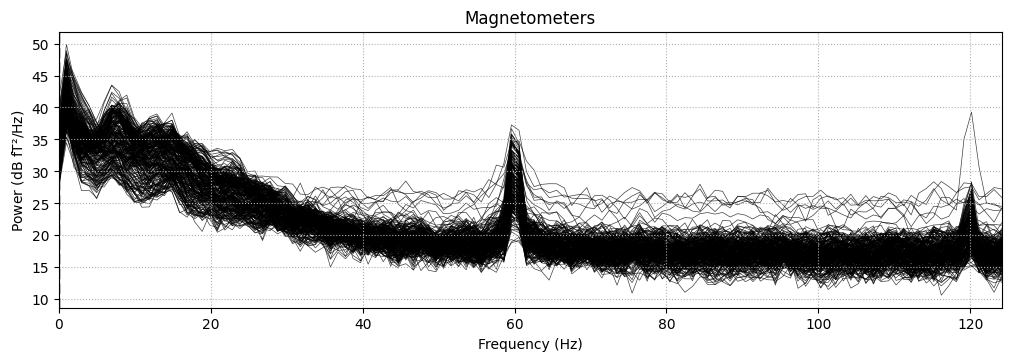

In [44]:
raws[0].compute_psd(fmax=125).plot(picks="data", amplitude=False)


Plotting task: rest


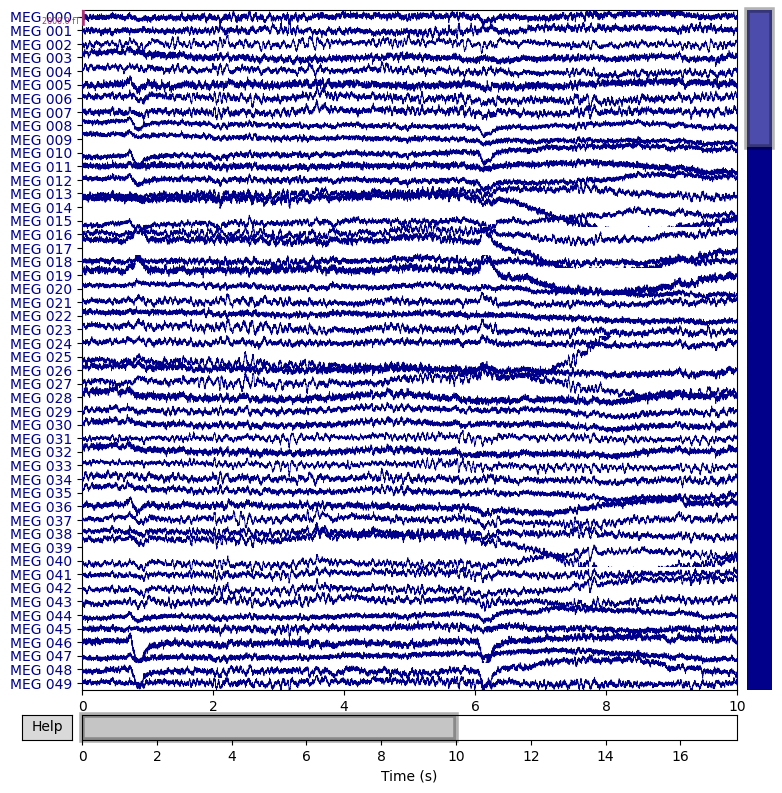

Plotting task: motor


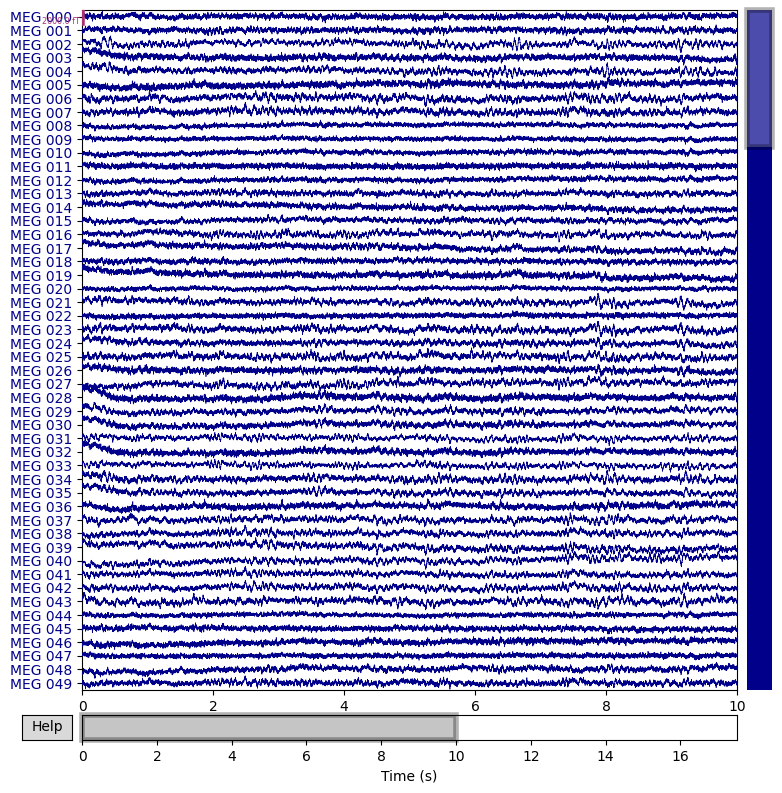

Plotting task: story_math


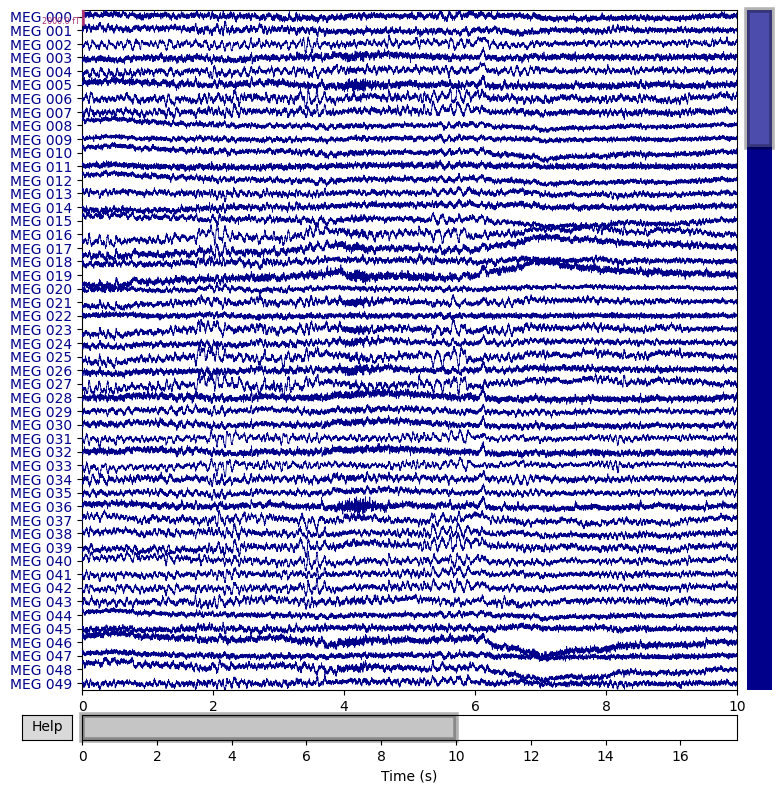

Plotting task: working_memory


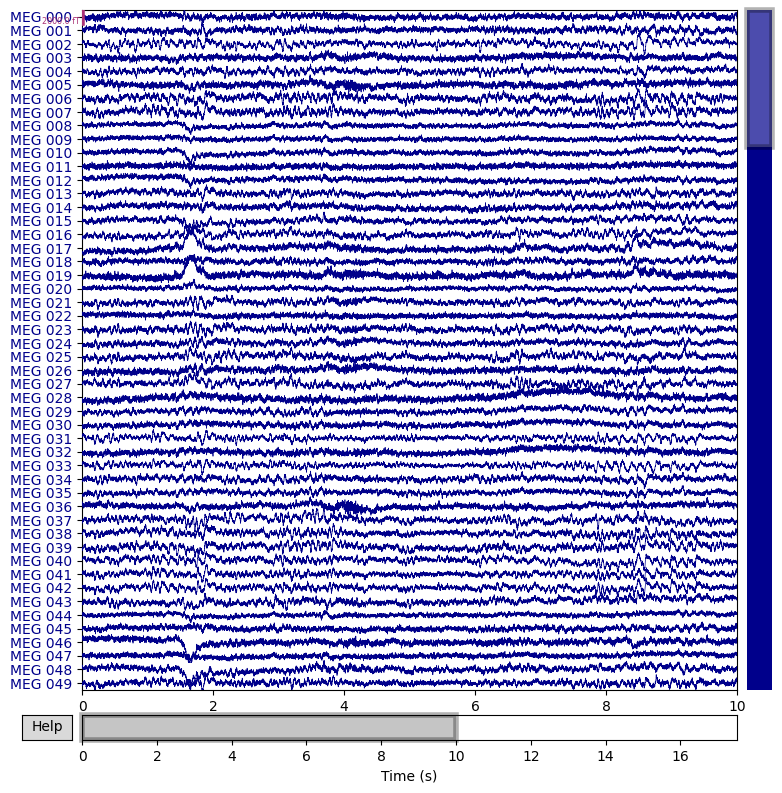

In [45]:
from collections import defaultdict

# Group raw objects by task
task_to_raws = defaultdict(list)
for raw, label in zip(raws, labels):
    task_to_raws[label].append(raw)

# Plot EXAMPLE of FILE from EACH TASK   
for task, raw_list in task_to_raws.items():
    print(f"Plotting task: {task}")
    # First trail each task
    raw_list[0].plot(n_channels=50, title=f'Task: {task}')


## Data info

In [3]:
single_sample = raws[0]
print(f"Number of recordings: {len(raws)}")
print(f"Unique tasks: {set(labels)}")
print(f"Info: {single_sample.info}")
data, times = single_sample[:, :]  # shape: (n_channels, n_times)
print("Min value:", data.min())
print("Max value:", data.max())

Number of recordings: 32
Unique tasks: {'rest', 'working_memory', 'motor', 'story_math'}
Info: <Info | 7 non-empty values
 bads: []
 ch_names: MEG 000, MEG 001, MEG 002, MEG 003, MEG 004, MEG 005, MEG 006, ...
 chs: 248 Magnetometers
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1017.0 Hz
 meas_date: unspecified
 nchan: 248
 projs: []
 sfreq: 2034.0 Hz
>
Min value: -2.788253829211218e-11
Max value: 1.3240070498299339e-11


# Data pre-processing

## Identyfing bad channels

In [4]:
from mne.preprocessing import find_bad_channels_lof
from collections import Counter

def identify_bad_channels(data, verbose = 0):
  all_bads = []
  bad_channels_per_trial = []

  for i, raw in enumerate(data):
      bads = mne.preprocessing.find_bad_channels_lof(raw, verbose = 0)
      bad_channels_per_trial.append(bads)
      if verbose == 1:
        print(f"Trial {i} - identified {len(bads)} bad channels: {bads}")

  # Count occurrences of each bad channel across all trials
  all_bad_channels = [ch for trial_bads in bad_channels_per_trial for ch in trial_bads]
  bad_counts = Counter(all_bad_channels)

  # Channels that appear as bad in every trial (count == number of trials)
  bad_in_all_trials = [ch for ch, count in bad_counts.items() if count == len(data)]

  if verbose == 1:
    print("Channels bad in all trials:", bad_in_all_trials)

  return bad_in_all_trials, bad_channels_per_trial


bad_in_all_trials, bad_channels_per_trial = identify_bad_channels(raws, verbose = 1)

Trial 0 - identified 18 bad channels: ['MEG 014', 'MEG 015', 'MEG 017', 'MEG 025', 'MEG 073', 'MEG 091', 'MEG 109', 'MEG 112', 'MEG 141', 'MEG 144', 'MEG 184', 'MEG 211', 'MEG 218', 'MEG 223', 'MEG 225', 'MEG 231', 'MEG 233', 'MEG 236']
Trial 1 - identified 8 bad channels: ['MEG 015', 'MEG 056', 'MEG 184', 'MEG 188', 'MEG 218', 'MEG 223', 'MEG 228', 'MEG 236']
Trial 2 - identified 8 bad channels: ['MEG 015', 'MEG 056', 'MEG 188', 'MEG 194', 'MEG 218', 'MEG 223', 'MEG 228', 'MEG 236']
Trial 3 - identified 9 bad channels: ['MEG 015', 'MEG 056', 'MEG 149', 'MEG 188', 'MEG 194', 'MEG 218', 'MEG 223', 'MEG 228', 'MEG 236']
Trial 4 - identified 9 bad channels: ['MEG 015', 'MEG 056', 'MEG 149', 'MEG 188', 'MEG 194', 'MEG 218', 'MEG 223', 'MEG 228', 'MEG 236']
Trial 5 - identified 9 bad channels: ['MEG 015', 'MEG 056', 'MEG 149', 'MEG 188', 'MEG 194', 'MEG 218', 'MEG 223', 'MEG 228', 'MEG 236']
Trial 6 - identified 10 bad channels: ['MEG 009', 'MEG 015', 'MEG 056', 'MEG 149', 'MEG 188', 'MEG 1

### Dropping common bad channels

In [5]:
for i, raw in enumerate(raws):  # raw_trials is your list of 32 mne.io.Raw objects
    raws[i] = raw.copy().drop_channels(bad_in_all_trials)

### Data info after dropping bad channels

In [6]:
single_sample = raws[23]
print(f"Number of recordings: {len(raws)}")
print(f"Unique tasks: {set(labels)}")
print(f"Info: {single_sample.info}")
data, times = single_sample[:, :]  # shape: (n_channels, n_times)
print("Min value:", data.min())
print("Max value:", data.max())

Number of recordings: 32
Unique tasks: {'rest', 'working_memory', 'motor', 'story_math'}
Info: <Info | 7 non-empty values
 bads: []
 ch_names: MEG 000, MEG 001, MEG 002, MEG 003, MEG 004, MEG 005, MEG 006, ...
 chs: 247 Magnetometers
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1017.0 Hz
 meas_date: unspecified
 nchan: 247
 projs: []
 sfreq: 2034.0 Hz
>
Min value: -1.1468772112555037e-11
Max value: 8.93078059421848e-12


## Bandpass Filtering, Downsampling, Normalization and Augmentation

In [7]:
def bandpass_filter(data, low_freq, high_freq):
  data_copy = data.copy()
  for raw in data_copy:
    raw.filter(l_freq=low_freq, h_freq=high_freq, filter_length='auto', verbose = False)
  return data_copy

def downsampling(data, new_freq):
  resampled_raws = []
  for entry in data:
      resampled = entry.copy().resample(new_freq, verbose=False)
      resampled_raws.append(resampled)

  resampled_arr = [raw.get_data() for raw in resampled_raws]  # each shape: (channels, times)

  # Convert to numpy array of shape (samples, channels, times)
  data = np.stack(resampled_arr)  # shape: (n_samples, n_channels, n_times)

  return data


def epoching_numpy(data, labels, sfreq, epoch_duration, overlap=0.3):
    """
    Epochs the downsampled MEG data.

    Args:
        data: np.ndarray of shape (n_trials, n_channels, n_times)
        labels: list of str, one per trial (e.g., 'motor', etc.)
        sfreq: sampling frequency of the d data
        epoch_duration: duration in seconds for each epoch
        overlap: proportion of overlap between epochs [0, 1)

    Returns:
        epoched_data: np.ndarray of shape (n_epochs, n_channels, epoch_samples)
        epoched_labels: list of str, task label for each epoch
        trial_ids: list of int, original trial index for each epoch
    """

    epoched_data = []
    epoched_labels = []
    trial_ids = []

    samples_per_epoch = int(epoch_duration * sfreq)
    step_size = int(samples_per_epoch * (1 - overlap))

    for trial_idx, (trial_data, label) in enumerate(zip(data, labels)):
        n_times = trial_data.shape[1]
        start_indices = np.arange(0, n_times - samples_per_epoch + 1, step_size)

        for start in start_indices:
            end = start + samples_per_epoch
            epoch = trial_data[:, start:end]  # shape: (n_channels, epoch_samples)
            epoched_data.append(epoch)
            epoched_labels.append(label)
            trial_ids.append(trial_idx)

    epoched_data = np.stack(epoched_data)  # shape: (n_epochs, n_channels, epoch_samples)

    return epoched_data, epoched_labels, trial_ids


def zscore_per_trial(trial, scale_factor=1e-1):
    mean = trial.mean(axis=1, keepdims=True)  # mean per channel
    std = trial.std(axis=1, keepdims=True)    # std per channel
    normalized = (trial - mean) / std
    normalized *= scale_factor                # keep the scale of the features in [0,1]
    return normalized



In [ ]:
filtered_data = bandpass_filter(raws, 1, 40)
downsampled_data = downsampling(filtered_data, 250)


In [15]:
from scipy.stats import zscore
import numpy as np

scale_factor = 1e-1

# Normalize each trial independently and apply scale factor
downsampled_data_norm = np.array([
    zscore(trial, axis=0) * scale_factor
    for trial in downsampled_data
])


### Plotting

Text(0.5, 1.0, 'Before Normalization & Rescaling')

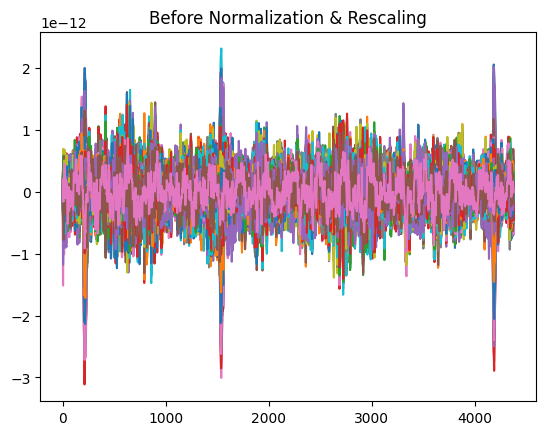

In [16]:
plt.plot(downsampled_data[0].transpose(1,0))
plt.title(f"Before Normalization & Rescaling")

Text(0.5, 1.0, 'After Normalization & Rescaling')

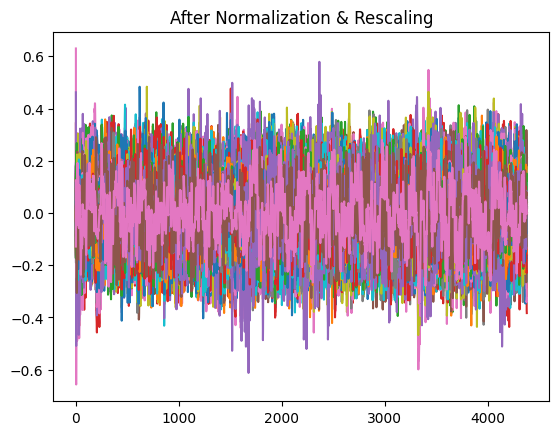

In [18]:
plt.plot(zscore_per_trial(downsampled_data_norm[0].transpose(1,0)))
plt.title(f"After Normalization & Rescaling")

## Classification Models

In [19]:
import numpy as np
import keras  # Only if needed elsewhere (e.g., keras.utils, keras.backend)

# Keras Core
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sklearn
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score




def baseline(data, num_classes=4, cnn1 = 32, cnn2 = 64, dropout = None, lr = 0.01):
    model = Sequential([
        Input(shape=(data.shape[1], data.shape[2])),  # (time, channels)
        Conv1D(cnn1, kernel_size=15, activation='relu', padding='same'),
        MaxPooling1D(pool_size=4),
        Conv1D(cnn2, kernel_size=7, activation='relu', padding='same'),
        GlobalAveragePooling1D(),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(keras.optimizers.Adam(learning_rate= lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# def cnn_lstm(data, num_classes=4):
#     model = Sequential([
#                         Input(shape = (data.shape[1], data.shape[2])), # (time, channels)
#                         Conv1D(32, kernel_size=15, activation='relu'),
#                         MaxPooling1D(pool_size=4),  # → ~1095 timepoints
#                         Conv1D(64, kernel_size=7, activation='relu', padding='same'),
#                         MaxPooling1D(pool_size=2),
#                         LayerNormalization(),
#                         LSTM(32, return_sequences=True),
#                         GlobalAveragePooling1D(),
#                         Dropout(0.4), # to improve generalization
#                         Dense(num_classes, activation='softmax')
#                     ])
#     model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model



def baseline_plus(data, num_classes=4, cnn1 = 64, cnn2 = 128, dropout = 0.2, lr = 0.01):
    model = Sequential([
        # Shape: (247 channels, 1000 time)
        Input(shape=(data.shape[1], data.shape[2])),

        Conv1D(cnn1, kernel_size=15, padding='same'),
        BatchNormalization(),          # light BN → stabilises training
        Activation('relu'),
        MaxPooling1D(pool_size=4),
        Dropout(dropout),                 # small, won’t under‑fit

        Conv1D(cnn2, kernel_size=7, padding='same'),
        BatchNormalization(),
        Activation('relu'),

        GlobalAveragePooling1D(),      # keeps params low
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate= lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### LOOCV 

In [20]:
'''
def train_LOOCV(data, labels, build_model_fn, epochs=10, batch_size=4):

    # data, labels = shuffle(data, labels, random_state=42)
    loo = LeaveOneOut()
    y_true, y_pred = [], []

    val_accuracies = []
    val_losses = []

    for i, (train_index, val_index) in enumerate(loo.split(data,labels)):
        print(f"Fold {i+1}")


        # Split data
        X_train, X_val = data[train_index], data[val_index]
        y_train, y_val = labels[train_index], labels[val_index]

        X_train, y_train = shuffle(X_train, y_train, random_state=42)
        X_val, y_val = shuffle(X_val, y_val, random_state=42)


        print("Before norm train:", np.mean(X_train), np.std(X_train), 'val:', np.mean(X_val), np.std(X_val))

        X_train = np.array([zscore_per_trial(trial) for trial in X_train])
        X_val = np.array([zscore_per_trial(trial) for trial in X_val])

        print("After norm train:", np.mean(X_train), np.std(X_train), 'val:', np.mean(X_val), np.std(X_val))

        print(f"Training on {len(X_train)} samples, validating on {len(y_val)} sample.")
        print(f"Train label distribution: {np.bincount(y_train)}")
        print(f"Validation label: {y_val}")


        # Create and train model
        model = build_model_fn(X_train, num_classes=4)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        # Evaluate
        y_true.extend(y_val)
        prediction = model.predict(X_val).argmax(axis=1)
        y_pred.extend(prediction)

        print('True label:',y_val, 'Predicted label:', prediction)

        val_accuracies.append((prediction[0] == y_val[0]).astype(float)) # take the last prediction (either 0 or 1) per fold
        val_losses.append(history.history['val_loss'][-1])               # take the last validatio loss per fold

    mean_acc = np.mean(val_accuracies)
    std_acc = np.std(val_accuracies)
    mean_loss = np.mean(val_losses)

    print(f"Mean Validation Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Mean Validation Loss: {mean_loss:.4f}")

    return y_true, y_pred, history, val_accuracies, val_losses

'''

'\ndef train_LOOCV(data, labels, build_model_fn, epochs=10, batch_size=4):\n\n    # data, labels = shuffle(data, labels, random_state=42)\n    loo = LeaveOneOut()\n    y_true, y_pred = [], []\n\n    val_accuracies = []\n    val_losses = []\n\n    for i, (train_index, val_index) in enumerate(loo.split(data,labels)):\n        print(f"Fold {i+1}")\n\n\n        # Split data\n        X_train, X_val = data[train_index], data[val_index]\n        y_train, y_val = labels[train_index], labels[val_index]\n\n        X_train, y_train = shuffle(X_train, y_train, random_state=42)\n        X_val, y_val = shuffle(X_val, y_val, random_state=42)\n\n\n        print("Before norm train:", np.mean(X_train), np.std(X_train), \'val:\', np.mean(X_val), np.std(X_val))\n\n        X_train = np.array([zscore_per_trial(trial) for trial in X_train])\n        X_val = np.array([zscore_per_trial(trial) for trial in X_val])\n\n        print("After norm train:", np.mean(X_train), np.std(X_train), \'val:\', np.mean(X_val),

In [21]:
#y_true, y_pred, history, val_accuracies, val_losses = train_LOOCV(X, y, baseline)
#plot_confusion_matrix(y_true, y_pred, class_names)
#print(classification_report(y_true, y_pred))
#y_true, y_pred, history, val_accuracies, val_losses = train_LOOCV(X, y, cnn_lstm)
#plot_confusion_matrix(y_true, y_pred, class_names)
#print(classification_report(y_true, y_pred))

### Stratified KFolds

#### Data augmentaton >> overlapping epochs

In [22]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

epoched_data, epoched_labels, trial_ids = epoching_numpy(downsampled_data, labels, 250, 4, 0.5)

# Transpose for model input shape (n_epochs, n_times, n_channels)
X_epoched = epoched_data.transpose(0, 2, 1)

print(X_epoched.shape)

# Encode labels
y_epoched = label_encoder.fit_transform(epoched_labels)
print(len(y_epoched))

(224, 1000, 247)
224


In [23]:
#print('Shape of epoched data:', epoched_data.shape)
##print('Shape of epoched labels:', len(epoched_labels))
#print('Shape of trial ids:', len(trial_ids))


In [27]:

from sklearn.model_selection import StratifiedGroupKFold

def train_group_kfold(data, labels, trial_ids, build_model_fn, n_splits=8, epochs=10, batch_size=8, verbose=1):
    gkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_true, y_pred = [], []

    val_accuracies = []
    val_losses = []

    for i, (train_i, val_i) in enumerate(gkf.split(data, labels, trial_ids)):
        print(f"Fold {i+1}/{n_splits}")
        # print(f"Train indices: {train_i}")
        # print(f"Validation indices: {val_i}")

        # Split
        X_train, X_val = data[train_i], data[val_i]
        y_train, y_val = labels[train_i], labels[val_i]

        val_perm = np.random.permutation(len(y_val))
        X_val, y_val = X_val[val_perm], y_val[val_perm]

        print("Before norm train:", np.mean(X_train), np.std(X_train), 'val:', np.mean(X_val), np.std(X_val))
        X_train = np.array([zscore_per_trial(trial) for trial in X_train])
        X_val = np.array([zscore_per_trial(trial) for trial in X_val])
        print("After norm train:", np.mean(X_train), np.std(X_train), 'val:', np.mean(X_val), np.std(X_val))

        # print("Train stats (pre-normalised):", np.mean(X_train), np.std(X_train))
        # print("Val stats (pre-normalised):", np.mean(X_val), np.std(X_val))

        # print(f"Training on {len(X_train)} samples, validating on {len(y_val)} samples.")
        # print(f"Train label distribution: {np.bincount(y_train)}")
        # print(f"Validation labels: {y_val}")

        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=verbose)

        # Train
        model = build_model_fn(X_train, num_classes=4)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=es,
            verbose=verbose
        )

        # Evaluate
        y_true.extend(y_val)
        y_pred.extend(model.predict(X_val).argmax(axis=1))

        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)


    mean_acc = np.mean(val_accuracies)
    std_acc = np.std(val_accuracies)
    mean_loss = np.mean(val_losses)

    print(f"Mean Validation Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Mean Validation Loss: {mean_loss:.4f}")

    return y_true, y_pred, history, val_accuracies, val_losses


In [ ]:
#y_true, y_pred, history, val_accuracies, val_losses = train_group_kfold(X_epoched, y_epoched, trial_ids, baseline_plus)

## HP TUNNING

In [25]:
!pip install keras-tuner

^C



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import keras_tuner as kt
from keras_tuner import BayesianOptimization


# Bseline model
def baseline_plus(data, num_classes=4, cnn1=64, cnn2=128, dropout=0.2, lr=0.01):
    model = Sequential([
        Input(shape=(data.shape[1], data.shape[2])),
        Conv1D(cnn1, kernel_size=15, padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling1D(pool_size=4),
        Dropout(dropout),
        Conv1D(cnn2, kernel_size=7, padding='same'),
        BatchNormalization(),
        Activation('relu'),
        GlobalAveragePooling1D(),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Global input data shape used by build_model
input_data = X_epoched

# Model builder function
def build_model(hp):
    cnn1 = hp.Int('cnn1', min_value=32, max_value=128, step=32)
    cnn2 = hp.Int('cnn2', min_value=32, max_value=128, step=32)
    dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    lr = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
    return baseline_plus(input_data, num_classes=4, cnn1=cnn1, cnn2=cnn2, dropout=dropout, lr=lr)

# Custom tuner class using Bayesian Optimization
class MyBayesianTuner(kt.BayesianOptimization):
    def run_trial(self, trial, data, labels, trial_ids):
        hp = trial.hyperparameters
        batch_size = hp.Choice('batch_size', [4, 8, 16])
        epochs = hp.Int('epochs', 10, 30, step=10)

        cnn1 = hp.get('cnn1')
        cnn2 = hp.get('cnn2')
        dropout = hp.get('dropout')
        lr = hp.get('lr')

        def model_fn(X_train, num_classes):
            return baseline_plus(X_train, num_classes, cnn1, cnn2, dropout, lr)

        y_true, y_pred, history, val_accuracies, val_losses = train_group_kfold(
            data=data,
            labels=labels,
            trial_ids=trial_ids,
            build_model_fn=model_fn,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        self.oracle.update_trial(
            trial.trial_id,
            metrics={
                "val_accuracy": np.mean(val_accuracies),
                "val_loss": np.mean(val_losses)
            }
        )

# Instantiate tuner
tuner = MyBayesianTuner(
    hypermodel=build_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=10,
    overwrite=True,
    directory="tuner_logs",
    project_name="meg_tuning",
)

# Run the search
tuner.search(
    X_epoched,
    y_epoched,
    trial_ids=trial_ids  # this passes to run_trial as kwargs

)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
32                |32                |cnn1
96                |96                |cnn2
0.2               |0.2               |dropout
0.0045108         |0.0045108         |lr

Fold 1/8
Before norm train: -6.1066689158481256e-18 2.612869372442138e-13 val: -2.0653488003882612e-16 2.340962097249676e-13
After norm train: 5.288305161500477e-21 0.10000000000000006 val: 5.779067218985778e-20 0.1000000000000001
Epoch 1/10


KeyboardInterrupt: 

In [29]:
tuned_params = tuner.get_best_hyperparameters()[0].values
print(tuned_params)

{'cnn1': 32, 'cnn2': 96, 'dropout': 0.2, 'lr': 0.004510768634394355, 'batch_size': 4, 'epochs': 10}


In [ ]:
cnn1 = tuned_params['cnn1']
cnn2 = tuned_params['cnn2']
dropout = tuned_params['dropout']
lr = tuned_params['lr']
batch_size = tuned_params['batch_size']
epochs = tuned_params['epochs']

In [ ]:
best_model = baseline_plus(X_epoched, num_classes=4, cnn1=96, cnn2=32, dropout=0.3, lr=0.001)
best_model.summary()

## TRAINING THE BEST MODEL

### Normalising the whole train set and saving stats

In [30]:
import numpy as np

X_reshaped = X_epoched.reshape(-1, X_epoched.shape[2])  # (samples * times, channels)

mean = np.mean(X_reshaped, axis=0)  # shape: (channels,)
std = np.std(X_reshaped, axis=0)

# Save stats
np.savez('final_scaler_stats.npz', mean=mean, std=std)

scale_factor = 1e-1
X_epoched_norm = ((X_epoched - mean[None, None, :]) / std[None, None, :]) * scale_factor

### Training best on whole train set

In [31]:
best_model = baseline_plus(
    X_epoched_norm,
    num_classes=4,
    cnn1=96,
    cnn2=32,
    dropout=0.3,
    lr=0.001
)

history = best_model.fit(
    X_epoched_norm,
    y_epoched,
    epochs=10,
    batch_size=4,
    verbose=1
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.3165 - loss: 1.3561
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.7162 - loss: 1.0373
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7904 - loss: 0.8867
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8635 - loss: 0.7171
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9269 - loss: 0.5480
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8377 - loss: 0.5963
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9395 - loss: 0.4231
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9448 - loss: 0.4491
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9753 - loss: 0.3062
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9861 - loss: 0.2926


## Testing

### Loading & Preprocessing & Normalising test set

In [32]:
test_raws, test_labels, test_info = create_dataset(intra_test_dir)
print(f"Loaded {len(test_raws)} raw test trials")

for i, raw in enumerate(test_raws):
    test_raws[i] = raw.copy().drop_channels(bad_in_all_trials)
print(f"After dropping bad channels, trial 0 shape: {test_raws[0].get_data().shape}")

filtered_test = bandpass_filter(test_raws, 1, 40)
print(f"Filtered test data, trial 0 shape: {filtered_test[0].get_data().shape}")

downsampled_test = downsampling(filtered_test, 250)


epoched_test, epoched_labels_test, trial_ids_test = epoching_numpy(
    downsampled_test,
    test_labels,
    250,
    4,
    0.5
)
print(f"Epoched test data shape: {epoched_test.shape}")  # (n_epochs, n_times, n_channels)
print(f"Epoched test labels length: {len(epoched_labels_test)}")
print(f"Trial IDs length: {len(trial_ids_test)}")

X_epoched_test = epoched_test.transpose(0, 2, 1)
print(f"X_epoched_test shape (samples, times, channels): {X_epoched_test.shape}")

y_epoched_test = label_encoder.transform(epoched_labels_test)
print(f"Encoded test labels length: {len(y_epoched_test)}")


Loaded 8 raw test trials
After dropping bad channels, trial 0 shape: (247, 35624)
Filtered test data, trial 0 shape: (247, 35624)
Epoched test data shape: (56, 247, 1000)
Epoched test labels length: 56
Trial IDs length: 56
X_epoched_test shape (samples, times, channels): (56, 1000, 247)
Encoded test labels length: 56


In [33]:
# Check shapes
print("X_epoched_test shape:", X_epoched_test.shape)  # (n_samples, n_times, n_channels)
print("mean_train shape:", mean.shape)          # (n_channels,)
print("std_train shape:", std.shape)            # (n_channels,)

# Normalize test data per channel
X_epoched_test_norm = (X_epoched_test - mean) / std

# Apply scale factor if needed
scale_factor = 1e-1
X_epoched_test_norm *= scale_factor

print("Normalized test data shape:", X_epoched_test_norm.shape)

scaler_stats = np.load('final_scaler_stats.npz')
mean = scaler_stats['mean']
std = scaler_stats['std']

X_epoched_test shape: (56, 1000, 247)
mean_train shape: (247,)
std_train shape: (247,)
Normalized test data shape: (56, 1000, 247)


### Evaluation

In [34]:
test_loss, test_acc = best_model.evaluate(X_epoched_test_norm, y_epoched_test, verbose=1)
print(f"\n Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9881 - loss: 0.2574

 Test Accuracy: 0.9821
